# 08 – Summary Statistics: Citation Relationships

This notebook analyses **citation relationships** between EC antitrust cases and CJEU cases.
All statistics are computed on **unique citation edges** (deduplicated source–target pairs).

**Groups:**
- `EC` – European Commission antitrust decisions
- `C` – Court of Justice cases (prefix `C-`)
- `T` – General Court / Court of First Instance cases (prefix `T-` or `F-`)
- `old unprefixed` – early CJEU cases without a letter prefix (e.g. `6/64`)

## 1. Imports and Configuration

In [33]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

DATA_DIR = Path("data/processed")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
print("Configuration loaded.")

Configuration loaded.


## 2. Load Input Files

In [34]:
def load_csv(path):
    p = Path(path)
    if not p.exists():
        print(f"  [MISSING] {p}")
        return pd.DataFrame()
    df = pd.read_csv(p, dtype=str)
    print(f"  [OK] {p.name}: {len(df):,} rows")
    return df

print("Loading files...")
ec_master         = load_csv(DATA_DIR / "ec_antitrust_master.csv")
cjeu_cases        = load_csv(DATA_DIR / "cjeu_cases.csv")
cjeu_ec_matches   = load_csv(DATA_DIR / "cjeu_ec_case_matches.csv")
ec_ec_matches     = load_csv(DATA_DIR / "ec_ec_case_matches.csv")
cjeu_cjeu_matches = load_csv(DATA_DIR / "cjeu_cjeu_case_matches.csv")

Loading files...
  [OK] ec_antitrust_master.csv: 1,185 rows
  [OK] cjeu_cases.csv: 3,018 rows
  [OK] cjeu_ec_case_matches.csv: 666 rows
  [OK] ec_ec_case_matches.csv: 485 rows
  [OK] cjeu_cjeu_case_matches.csv: 6,763 rows


## 3. Classify CJEU Cases into Groups

In [35]:
_CELEX_RE = re.compile(
    r"^6(?P<year>\d{4})(?P<court>CJ|TJ|FJ)(?P<number>\d+)$",
    re.IGNORECASE,
)
_COURT_MAP = {"CJ": "C", "TJ": "T", "FJ": "F"}


def derive_case_number(celex_id):
    m = _CELEX_RE.match(str(celex_id).strip())
    if not m:
        return ""
    court  = _COURT_MAP.get(m.group("court").upper(), "")
    number = str(int(m.group("number")))
    year   = m.group("year")[-2:]
    return f"{court}-{number}/{year}"


def classify_cjeu(case_number):
    s = str(case_number).strip()
    if s.startswith("C-"):
        return "CJEU_C"
    if s.startswith("T-") or s.startswith("F-"):
        return "CJEU_T"
    if re.match(r"^\d+/\d+$", s):
        return "CJEU_old_unprefixed"
    return "CJEU_other"


if not cjeu_cases.empty:
    cjeu_cases["case_number"] = cjeu_cases["celex_id"].apply(derive_case_number)
    cjeu_cases["group"]       = cjeu_cases["case_number"].apply(classify_cjeu)
    print(cjeu_cases["group"].value_counts().to_string())

group
CJEU_C        1817
CJEU_T         751
CJEU_other     450


## 4. Basic Overview

A minimal overview of the dataset: number of cases in each group.
The unit of observation is one case or decision.

In [36]:
n_ec   = len(ec_master)
n_cjeu = len(cjeu_cases)
grp_counts = cjeu_cases["group"].value_counts() if not cjeu_cases.empty else pd.Series(dtype=int)
n_cjeu_c   = int(grp_counts.get("CJEU_C", 0))
n_cjeu_t   = int(grp_counts.get("CJEU_T", 0))

overview = pd.DataFrame({
    "Group": ["EC cases", "CJEU cases (total)", "C cases (C-...)", "T cases (T-/F-...)"],
    "Count": [n_ec, n_cjeu, n_cjeu_c, n_cjeu_t],
})
display(overview)

,Group,Count
0,EC cases,1185
1,CJEU cases (total),3018
2,C cases (C-...),1817
3,T cases (T-/F-...),751


## 5. Deduplicate into Unique Citation Edges

All subsequent statistics are computed on **unique source–target pairs**.
This ensures that the same citation relationship is not counted multiple times
(e.g. when a document exists in multiple formats or languages).

In [37]:
def dedup_pairs(df, src_col, tgt_col):
    if df.empty:
        return pd.DataFrame(columns=[src_col, tgt_col])
    return df[[src_col, tgt_col]].drop_duplicates().reset_index(drop=True)

cjeu_ec_pairs   = dedup_pairs(cjeu_ec_matches,   "cjeu_celex_id",         "ec_case_number")
ec_ec_pairs     = dedup_pairs(ec_ec_matches,      "source_ec_case_number", "target_ec_case_number")
cjeu_cjeu_pairs = dedup_pairs(cjeu_cjeu_matches,  "source_celex_id",       "target_celex_id")

print(f"Unique CJEU->EC   edges : {len(cjeu_ec_pairs):,}")
print(f"Unique EC->EC     edges : {len(ec_ec_pairs):,}")
print(f"Unique CJEU->CJEU edges : {len(cjeu_cjeu_pairs):,}")

Unique CJEU->EC   edges : 666
Unique EC->EC     edges : 485
Unique CJEU->CJEU edges : 6,760


## 6. Unique Citation Relationships

This section shows how many unique directed citation edges exist in the dataset.
Each edge represents one case citing another — after deduplication.
- **CJEU → EC**: a CJEU judgment references an EC antitrust decision
- **EC → EC**: an EC decision references another EC decision
- **CJEU → CJEU**: a CJEU judgment references another CJEU judgment

In [38]:
edge_summary = pd.DataFrame({
    "Citation type": ["CJEU -> EC", "EC -> EC", "CJEU -> CJEU"],
    "Unique edges":  [len(cjeu_ec_pairs), len(ec_ec_pairs), len(cjeu_cjeu_pairs)],
})
display(edge_summary)

,Citation type,Unique edges
0,CJEU -> EC,666
1,EC -> EC,485
2,CJEU -> CJEU,6760


## 7. Out-Degree: How Much Do Cases Cite?

Out-degree measures how many unique outgoing citations each case/document produces.
The unit of observation is one case or document.
Cases with zero outgoing citations are included (degree = 0).

In [39]:
def extended_describe(s, name=""):
    """Returns count, mean, std, min, 25%, 50%, 75%, max, skew, kurtosis."""
    d = s.describe()
    d["skew"]     = s.skew()
    d["kurtosis"] = s.kurtosis()
    if name:
        d.name = name
    return d

# EC -> EC out-degree (per EC case)
if not ec_ec_pairs.empty and not ec_master.empty:
    ec_out      = ec_ec_pairs.groupby("source_ec_case_number").size()
    ec_out_full = ec_master["ec_case_number"].map(ec_out).fillna(0).astype(int)
    print("EC -> EC out-degree (outgoing EC citations per EC case):")
    display(extended_describe(ec_out_full, "EC->EC out-degree").to_frame())

# CJEU -> EC out-degree (per CJEU case), split by group
if not cjeu_ec_pairs.empty and not cjeu_cases.empty:
    cjeu_ec_out = cjeu_ec_pairs.groupby("cjeu_celex_id").size()
    cjeu_stats  = cjeu_cases[["celex_id", "group"]].copy()
    cjeu_stats["cjeu_ec_out"] = cjeu_stats["celex_id"].map(cjeu_ec_out).fillna(0).astype(int)
    print("\nCJEU -> EC out-degree (outgoing EC citations per CJEU case), by group:")
    rows = []
    for grp in ["CJEU_C", "CJEU_T"]:
        sub = cjeu_stats.loc[cjeu_stats["group"] == grp, "cjeu_ec_out"]
        rows.append(extended_describe(sub, grp))
    sub_old = cjeu_stats.loc[cjeu_stats["group"] == "CJEU_old_unprefixed", "cjeu_ec_out"]
    if len(sub_old) > 0:
        rows.append(extended_describe(sub_old, "CJEU_old_unprefixed (*)"))
    display(pd.DataFrame(rows))
    print("(*) Old unprefixed CJEU cases: treat with caution — citation matching may be less reliable.")

# CJEU -> CJEU out-degree (per CJEU case), split by group
if not cjeu_cjeu_pairs.empty and not cjeu_cases.empty:
    cjeu_cjeu_out = cjeu_cjeu_pairs.groupby("source_celex_id").size()
    cjeu_stats2   = cjeu_cases[["celex_id", "group"]].copy()
    cjeu_stats2["cjeu_cjeu_out"] = cjeu_stats2["celex_id"].map(cjeu_cjeu_out).fillna(0).astype(int)
    print("\nCJEU -> CJEU out-degree (outgoing CJEU citations per CJEU case), by group:")
    rows2 = []
    for grp in ["CJEU_C", "CJEU_T"]:
        sub = cjeu_stats2.loc[cjeu_stats2["group"] == grp, "cjeu_cjeu_out"]
        rows2.append(extended_describe(sub, grp))
    display(pd.DataFrame(rows2))

EC -> EC out-degree (outgoing EC citations per EC case):


,EC->EC out-degree
count,1185.000000
mean,0.409283
std,1.662000
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,19.000000
skew,6.316917
kurtosis,50.401986



CJEU -> EC out-degree (outgoing EC citations per CJEU case), by group:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
CJEU_C,1817.0,0.085856,0.350115,0.0,0.0,0.0,0.0,4.0,4.874804,28.311521
CJEU_T,751.0,0.593875,1.415689,0.0,0.0,0.0,1.0,11.0,3.872536,18.452080


(*) Old unprefixed CJEU cases: treat with caution — citation matching may be less reliable.

CJEU -> CJEU out-degree (outgoing CJEU citations per CJEU case), by group:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
CJEU_C,1817.0,1.351128,2.180457,0.0,0.0,1.0,2.0,19.0,3.046823,12.640604
CJEU_T,751.0,5.198402,6.487263,0.0,0.0,3.0,7.0,56.0,2.160156,7.447604


## 8. In-Degree: How Often Are Cases Cited?

In-degree measures how many unique incoming citations each case receives.
The unit of observation is one case or document.
Cases with zero incoming citations are included (degree = 0).

In [40]:
# EC cases cited by CJEU
if not cjeu_ec_pairs.empty and not ec_master.empty:
    ec_cited_by_cjeu = cjeu_ec_pairs.groupby("ec_case_number").size()
    ec_in_cjeu_full  = ec_master["ec_case_number"].map(ec_cited_by_cjeu).fillna(0).astype(int)
    print("In-degree: EC cases cited by CJEU documents (CJEU -> EC):")
    display(extended_describe(ec_in_cjeu_full, "EC in-degree (from CJEU)").to_frame())

# EC cases cited by EC
if not ec_ec_pairs.empty and not ec_master.empty:
    ec_cited_by_ec = ec_ec_pairs.groupby("target_ec_case_number").size()
    ec_in_ec_full  = ec_master["ec_case_number"].map(ec_cited_by_ec).fillna(0).astype(int)
    print("\nIn-degree: EC cases cited by EC documents (EC -> EC):")
    display(extended_describe(ec_in_ec_full, "EC in-degree (from EC)").to_frame())

# CJEU cases cited by CJEU
if not cjeu_cjeu_pairs.empty and not cjeu_cases.empty:
    cjeu_cited_by_cjeu = cjeu_cjeu_pairs.groupby("target_celex_id").size()
    cjeu_in_full       = cjeu_cases["celex_id"].map(cjeu_cited_by_cjeu).fillna(0).astype(int)
    print("\nIn-degree: CJEU cases cited by other CJEU documents (CJEU -> CJEU):")
    display(extended_describe(cjeu_in_full, "CJEU in-degree (from CJEU)").to_frame())

In-degree: EC cases cited by CJEU documents (CJEU -> EC):


,EC in-degree (from CJEU)
count,1185.000000
mean,0.655696
std,2.359842
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,41.000000
skew,8.108127
kurtosis,97.287953



In-degree: EC cases cited by EC documents (EC -> EC):


,EC in-degree (from EC)
count,1185.000000
mean,0.428692
std,1.137589
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,12.000000
skew,4.408991
kurtosis,26.829854



In-degree: CJEU cases cited by other CJEU documents (CJEU -> CJEU):


,CJEU in-degree (from CJEU)
count,3018.000000
mean,2.239894
std,7.974527
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,116.000000
skew,7.232904
kurtosis,70.005859


## 9. Concentration / Sparsity

This section shows how concentrated or sparse the citation network is.
Key questions: what share of cases never cite or are never cited?
And do a small number of cases account for most citations?

In [41]:
def sparsity_row(series_full, label):
    n      = len(series_full)
    n_zero = (series_full == 0).sum()
    n_pos  = n - n_zero
    return {
        "Variable":       label,
        "N cases":        n,
        "Zero citations": n_zero,
        "% zero":         round(100 * n_zero / n, 1) if n > 0 else 0,
        "At least one":   n_pos,
        "% at least one": round(100 * n_pos  / n, 1) if n > 0 else 0,
    }

sparsity_rows = []

if not ec_master.empty:
    if not ec_ec_pairs.empty:
        ec_out_s = ec_master["ec_case_number"].map(
            ec_ec_pairs.groupby("source_ec_case_number").size()).fillna(0).astype(int)
        sparsity_rows.append(sparsity_row(ec_out_s, "EC out-degree (EC->EC)"))
        ec_in_s  = ec_master["ec_case_number"].map(
            ec_ec_pairs.groupby("target_ec_case_number").size()).fillna(0).astype(int)
        sparsity_rows.append(sparsity_row(ec_in_s,  "EC in-degree (EC->EC)"))
    if not cjeu_ec_pairs.empty:
        ec_in_c  = ec_master["ec_case_number"].map(
            cjeu_ec_pairs.groupby("ec_case_number").size()).fillna(0).astype(int)
        sparsity_rows.append(sparsity_row(ec_in_c,  "EC in-degree (CJEU->EC)"))

if not cjeu_cases.empty:
    if not cjeu_ec_pairs.empty:
        cjeu_out_ec = cjeu_cases["celex_id"].map(
            cjeu_ec_pairs.groupby("cjeu_celex_id").size()).fillna(0).astype(int)
        sparsity_rows.append(sparsity_row(cjeu_out_ec, "CJEU out-degree (CJEU->EC)"))
    if not cjeu_cjeu_pairs.empty:
        cjeu_out_cj = cjeu_cases["celex_id"].map(
            cjeu_cjeu_pairs.groupby("source_celex_id").size()).fillna(0).astype(int)
        sparsity_rows.append(sparsity_row(cjeu_out_cj, "CJEU out-degree (CJEU->CJEU)"))
        cjeu_in_cj  = cjeu_cases["celex_id"].map(
            cjeu_cjeu_pairs.groupby("target_celex_id").size()).fillna(0).astype(int)
        sparsity_rows.append(sparsity_row(cjeu_in_cj,  "CJEU in-degree (CJEU->CJEU)"))

if sparsity_rows:
    display(pd.DataFrame(sparsity_rows))

,Variable,N cases,Zero citations,% zero,At least one,% at least one
0,EC out-degree (EC->EC),1185,1053,88.9,132,11.1
1,EC in-degree (EC->EC),1185,937,79.1,248,20.9
2,EC in-degree (CJEU->EC),1185,950,80.2,235,19.8
3,CJEU out-degree (CJEU->EC),3018,2635,87.3,383,12.7
4,CJEU out-degree (CJEU->CJEU),3018,1338,44.3,1680,55.7
5,CJEU in-degree (CJEU->CJEU),3018,2150,71.2,868,28.8


### 9a. Concentration: Top Cases' Share of All Citations

Do a small number of cases account for a large share of all citations?
The table below shows what share of total citations is captured by the top 1%, 5%, and 10% most-cited cases.

In [42]:
def concentration_row(counts_series, label):
    s     = counts_series.sort_values(ascending=False)
    total = s.sum()
    if total == 0:
        return {"Variable": label, "Total citations": 0}
    n   = len(s)
    row = {"Variable": label, "Total citations": int(total)}
    for pct in [1, 5, 10]:
        k = max(1, int(np.ceil(n * pct / 100)))
        row[f"Top {pct}% share (%)"] = round(100 * s.iloc[:k].sum() / total, 1)
    return row

conc_rows = []
if not cjeu_ec_pairs.empty:
    conc_rows.append(concentration_row(
        cjeu_ec_pairs.groupby("ec_case_number").size(), "EC in-degree (CJEU->EC)"))
if not ec_ec_pairs.empty:
    conc_rows.append(concentration_row(
        ec_ec_pairs.groupby("target_ec_case_number").size(), "EC in-degree (EC->EC)"))
if not cjeu_cjeu_pairs.empty:
    conc_rows.append(concentration_row(
        cjeu_cjeu_pairs.groupby("target_celex_id").size(), "CJEU in-degree (CJEU->CJEU)"))

if conc_rows:
    display(pd.DataFrame(conc_rows))

,Variable,Total citations,Top 1% share (%),Top 5% share (%),Top 10% share (%)
0,EC in-degree (CJEU->EC),666,12.8,30.8,42.0
1,EC in-degree (EC->EC),485,6.4,19.2,30.1
2,CJEU in-degree (CJEU->CJEU),6760,12.4,35.3,50.0


## 10. Top Cited / Top Citing Cases

Short lists of the most cited and most citing cases.
These are based on unique citation edges (deduplicated).

In [43]:
# Top 10 most cited EC cases (by CJEU)
if not cjeu_ec_pairs.empty:
    top_ec_cited = (
        cjeu_ec_pairs.groupby("ec_case_number").size()
        .sort_values(ascending=False).head(10)
        .reset_index(name="times_cited_by_CJEU")
    )
    print("Top 10 most cited EC cases (by CJEU documents):")
    display(top_ec_cited)

# Top 10 most citing CJEU documents (CJEU -> EC)
if not cjeu_ec_pairs.empty:
    top_cjeu_citing = (
        cjeu_ec_pairs.groupby("cjeu_celex_id").size()
        .sort_values(ascending=False).head(10)
        .reset_index(name="ec_cases_cited")
    )
    print("\nTop 10 most citing CJEU documents (outgoing CJEU->EC citations):")
    display(top_cjeu_citing)

# Top 10 most cited CJEU cases (by other CJEU)
if not cjeu_cjeu_pairs.empty:
    top_cjeu_cited = (
        cjeu_cjeu_pairs.groupby("target_celex_id").size()
        .sort_values(ascending=False).head(10)
        .reset_index(name="times_cited_by_CJEU")
    )
    print("\nTop 10 most cited CJEU cases (by other CJEU documents):")
    display(top_cjeu_cited)

Top 10 most cited EC cases (by CJEU documents):


,ec_case_number,times_cited_by_CJEU
0,IV/31149,41
1,AT.35691,25
2,IV/31865,19
3,IV/3344; IV/4,19
4,IV/4,19
5,IV/31553,18
6,AT.34466,16
7,AT.36545,14
8,IV/33133,12
9,IV/26267,11



Top 10 most citing CJEU documents (outgoing CJEU->EC citations):


,cjeu_celex_id,ec_cases_cited
0,61991TJ0019,11
1,61998TJ0191,11
2,61997TJ0228,11
3,62000TJ0224,8
4,62002TJ0038,8
5,61995TJ0213,8
6,61993TJ0024,8
7,61994TJ0348,7
8,62002TJ0059,7
9,62000TJ0213,7



Top 10 most cited CJEU cases (by other CJEU documents):


,target_celex_id,times_cited_by_CJEU
0,61980CJ0100,116
1,61976CJ0085,112
2,61962CJ0025,108
3,61981CJ0322,98
4,61973CJ0040,94
5,61982CJ0107,81
6,61981CJ0060,81
7,61969CJ0041,78
8,61969CJ0048,71
9,61985CJ0089,67


## 11. Time Dimension

Citations and cases per year. The year refers to the **citing** document (source).
This shows in which years citation activity was highest.

In [44]:
def citations_per_year(pairs_df, matches_df, date_col, src_col, label):
    """Counts unique edges per year using the date from the original match file."""
    if pairs_df.empty or matches_df.empty or date_col not in matches_df.columns:
        return pd.Series(dtype=int, name=label)
    date_map = matches_df[[src_col, date_col]].drop_duplicates(subset=[src_col])
    merged   = pairs_df.merge(date_map, on=src_col, how="left")
    yr       = pd.to_datetime(merged[date_col], errors="coerce").dt.year
    return yr.value_counts().sort_index().rename(label)

cjeu_ec_yr   = citations_per_year(cjeu_ec_pairs,   cjeu_ec_matches,   "cjeu_document_date",  "cjeu_celex_id",         "CJEU->EC")
ec_ec_yr     = citations_per_year(ec_ec_pairs,     ec_ec_matches,     "source_date",          "source_ec_case_number", "EC->EC")
cjeu_cjeu_yr = citations_per_year(cjeu_cjeu_pairs, cjeu_cjeu_matches, "source_document_date", "source_celex_id",       "CJEU->CJEU")

cit_yr = pd.concat([cjeu_ec_yr, ec_ec_yr, cjeu_cjeu_yr], axis=1).fillna(0).astype(int)
if not cit_yr.empty:
    print("Unique citation edges per year (last 30 years shown):")
    display(cit_yr.tail(30))
else:
    print("No date data available.")

Unique citation edges per year (last 30 years shown):


,CJEU->EC,EC->EC,CJEU->CJEU
2012.0,0,33,0
2013.0,0,7,0
2014.0,0,30,0
2015.0,0,3,0
2016.0,0,27,0
2017.0,0,13,0
2018.0,0,32,0
2019.0,0,28,0
2020.0,0,30,0
2021.0,0,41,0


### 11a. CJEU -> EC Citations per Year, by Group (C vs T)

Breakdown of CJEU->EC citations by group (C cases vs T cases) per year.
This shows whether C or T cases drive citation activity in particular periods.

In [45]:
if not cjeu_ec_pairs.empty and not cjeu_ec_matches.empty and not cjeu_cases.empty:
    grp_map  = cjeu_cases.set_index("celex_id")["group"]
    tmp      = cjeu_ec_pairs.copy()
    tmp["group"] = tmp["cjeu_celex_id"].map(grp_map)
    date_map = cjeu_ec_matches[["cjeu_celex_id", "cjeu_document_date"]].drop_duplicates(subset=["cjeu_celex_id"])
    tmp      = tmp.merge(date_map, on="cjeu_celex_id", how="left")
    tmp["year"] = pd.to_datetime(tmp["cjeu_document_date"], errors="coerce").dt.year
    yr_grp = (
        tmp.dropna(subset=["year", "group"])
        .query("group in ['CJEU_C','CJEU_T']")
        .groupby(["year", "group"]).size().unstack(fill_value=0)
    )
    if not yr_grp.empty:
        display(yr_grp.tail(30))
else:
    print("No data available for group breakdown.")

group,CJEU_C,CJEU_T
year,,
1979,4,0
1980,2,0
1982,1,0
1983,7,0
1984,6,0
1985,4,0
1986,2,0
1987,3,0
1988,1,0


### 11b. Cases per Year

Number of EC decisions and CJEU cases per year (by document date).

In [46]:
yr_rows = {}
if not ec_master.empty and "date" in ec_master.columns:
    yr_rows["EC decisions"] = (
        pd.to_datetime(ec_master["date"], errors="coerce").dt.year
        .value_counts().sort_index()
    )
if not cjeu_cases.empty and "document_date" in cjeu_cases.columns:
    for grp, label in [("CJEU_C", "CJEU C cases"), ("CJEU_T", "CJEU T cases")]:
        sub = cjeu_cases[cjeu_cases["group"] == grp]
        yr_rows[label] = (
            pd.to_datetime(sub["document_date"], errors="coerce").dt.year
            .value_counts().sort_index()
        )

if yr_rows:
    cases_yr = pd.DataFrame(yr_rows).fillna(0).astype(int)
    print("Cases/decisions per year (last 30 years shown):")
    display(cases_yr.tail(30))
else:
    print("No date data available.")

Cases/decisions per year (last 30 years shown):


,EC decisions,CJEU C cases,CJEU T cases
1996.0,1,48,28
1997.0,1,54,27
1998.0,4,64,44
1999.0,17,53,49
2000.0,18,80,25
2001.0,36,55,40
2002.0,33,77,55
2003.0,26,96,47
2004.0,21,71,40
2005.0,14,76,55


### 11c. Time Trend Plot

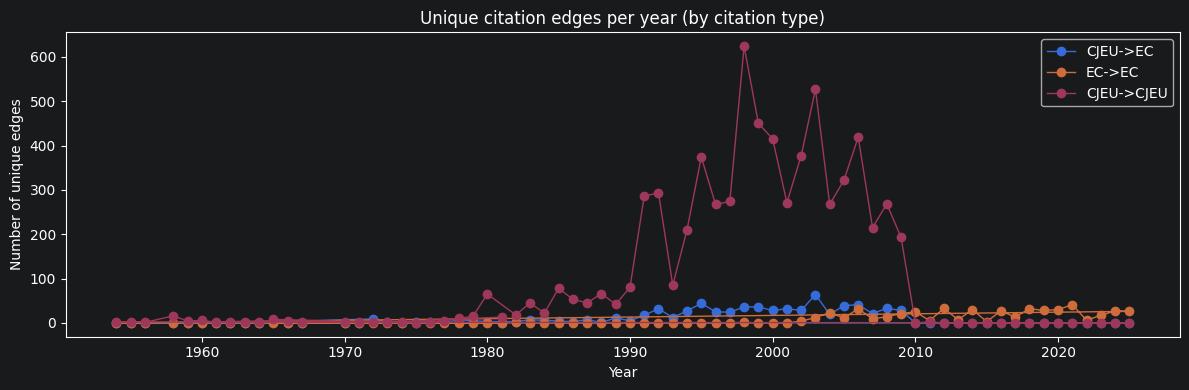

In [47]:
if HAS_MPL and not cit_yr.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    cit_yr.plot(ax=ax, marker="o", linewidth=1)
    ax.set_title("Unique citation edges per year (by citation type)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of unique edges")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib not available or no data.")

## 12. Final Summary

In [48]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print()
print(f"  EC cases:              {n_ec:,}")
print(f"  CJEU cases (total):    {n_cjeu:,}")
print(f"    of which C cases:    {n_cjeu_c:,}")
print(f"    of which T cases:    {n_cjeu_t:,}")
print()
print("Unique citation edges:")
print(f"  CJEU->EC  : {len(cjeu_ec_pairs):,}")
print(f"  EC->EC    : {len(ec_ec_pairs):,}")
print(f"  CJEU->CJEU: {len(cjeu_cjeu_pairs):,}")
print()
print("Done.")


SUMMARY

  EC cases:              1,185
  CJEU cases (total):    3,018
    of which C cases:    1,817
    of which T cases:    751

Unique citation edges:
  CJEU->EC  : 666
  EC->EC    : 485
  CJEU->CJEU: 6,760

Done.
